In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os #menejemenisasi file dan folder
import cv2
import numpy as np
from sklearn.utils import shuffle
from PIL import Image #library clean data
#library untuk menampilkan gambar
import matplotlib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

#library tensorflow untuk pelatihan model
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator #library untuk augmentasi gambar
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras import backend as k
from keras.preprocessing import image

In [16]:
#Direktori data
base_dir = '/content/drive/MyDrive/UTS/Dataset/'
#Direktori data daun sakit
brownspot_dir = os.path.join(base_dir, 'brown_spot')
#Direktori data daun sakit
leafsmut_dir = os.path.join(base_dir, 'Leaf smut')
#Direktori data daun sakit
tungro_dir = os.path.join(base_dir, 'tungro')

# cek dulu apakah folder ada
print(os.path.exists(brownspot_dir))
print(os.path.exists(leafsmut_dir))
print(os.path.exists(tungro_dir))

#Mengambil semua anama file dalam masing-masing direktori
brownspot_fnames = os.listdir(brownspot_dir)
leafsmut_fnames = os.listdir(leafsmut_dir)
tungro_fnames = os.listdir(tungro_dir)

True
True
True


In [18]:
#check file
print('total data diseased:',len(os.listdir(brownspot_dir)))
print('total data diseased:',len(os.listdir(leafsmut_dir)))
print('total data diseased:',len(os.listdir(tungro_dir)))

total data diseased: 300
total data diseased: 300
total data diseased: 300


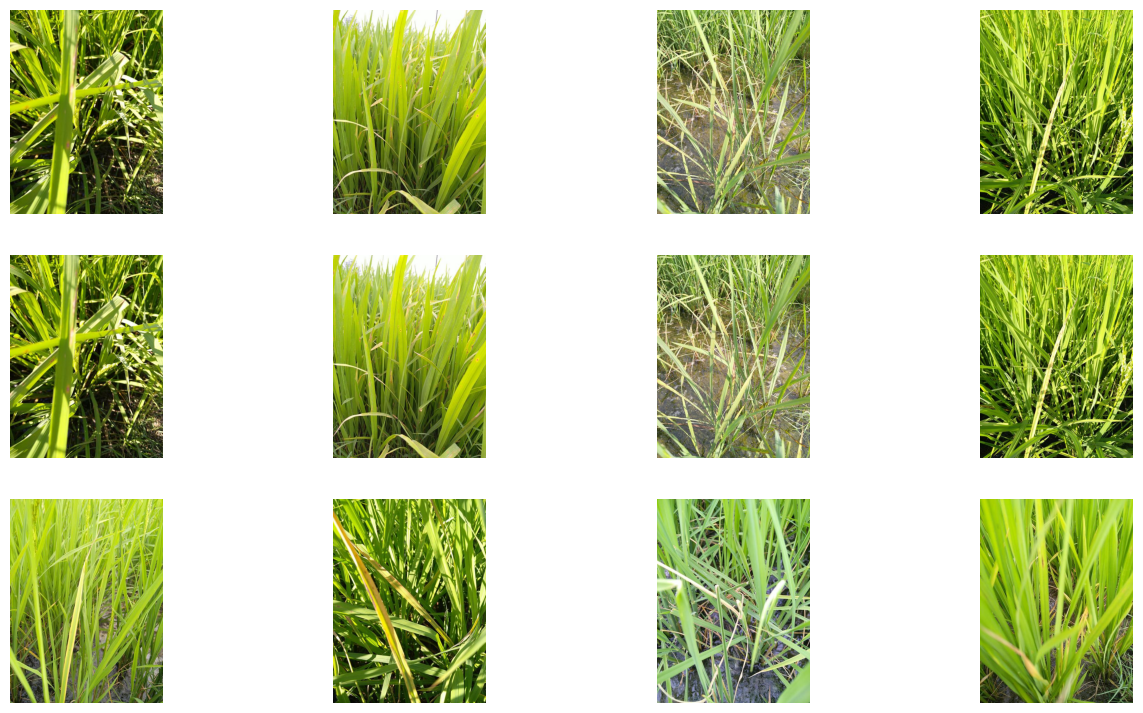

In [19]:
cols = 4
rows = 3

pic_index = 0
#menampilkan gambar file
img = plt.gcf()
img.set_size_inches(cols*4, rows*3)

pic_index+=4

#menyimpan ke dalam list nama file yang akan ditampilkan
show_brownspot_img = [os.path.join(brownspot_dir, fname)
                      for fname in brownspot_fnames[pic_index-4:pic_index]
                    ]

show_leafsmut_img = [os.path.join(leafsmut_dir, fname)
                      for fname in leafsmut_fnames[pic_index-4:pic_index]
                    ]
show_tungro_img = [os.path.join(tungro_dir, fname)
                      for fname in tungro_fnames[pic_index-4:pic_index]
                    ]
for i, img_path in enumerate(show_brownspot_img+show_brownspot_img+show_tungro_img):
  sp = plt.subplot(rows, cols, i + 1)
  sp.axis('off')

  image = mpimg.imread(img_path)
  plt.imshow(image)

plt.show()

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='wrap',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    shuffle=True,
    batch_size = 32,
    subset='training',
    class_mode = 'categorical'
)

validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224,224),
    batch_size = 32,
    subset='validation',
    class_mode = 'categorical'
)

Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.


In [21]:
print(train_generator.class_indices)

{'Leaf smut': 0, 'brown_spot': 1, 'tungro': 2}


In [22]:
#create model
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', input_shape= (224,224,3)),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64,(3,3), activation= 'relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128,(3,3), activation= 'relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128,(3,3), activation= 'relu'),
  tf.keras.layers.MaxPooling2D(2,2),


  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation= 'relu'),
  tf.keras.layers.Dense(512, activation= 'relu'),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(3, activation= 'softmax')
])

#menampilkan summary/keterangan dari model
model.summary()

model.compile(loss='categorical_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(),
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,942,723 (37.93 MB)

 Trainable params: 9,942,723 (37.93 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint
file_path = '/content/drive/MyDrive/UTS/Hasil Model/model-{epoch:02d}-{val_loss:.2f}.keras'
#Menyimpan model dengan kriteria tertentu
checkpoint = ModelCheckpoint(file_path,
                             monitor='val_loss',
                             save_best_only = True,
                             mode = 'min'
                            )

In [25]:
history = model.fit(
    train_generator,
    steps_per_epoch = len(train_generator),
    epochs = 50,
    callbacks=[checkpoint],
    validation_data = validation_generator,
    validation_steps =  len(validation_generator),
    verbose = 2
)

Epoch 1/50
23/23 - 302s - 13s/step - accuracy: 0.4472 - loss: 1.1747 - val_accuracy: 0.6889 - val_loss: 0.7568
Epoch 2/50
23/23 - 112s - 5s/step - accuracy: 0.6097 - loss: 0.7175 - val_accuracy: 0.6889 - val_loss: 0.5527
Epoch 3/50
23/23 - 113s - 5s/step - accuracy: 0.5889 - loss: 0.7633 - val_accuracy: 0.7056 - val_loss: 0.5122
Epoch 4/50
23/23 - 113s - 5s/step - accuracy: 0.6194 - loss: 0.6339 - val_accuracy: 0.7167 - val_loss: 0.4849
Epoch 5/50
23/23 - 139s - 6s/step - accuracy: 0.6694 - loss: 0.6425 - val_accuracy: 0.6667 - val_loss: 0.4891
Epoch 6/50
23/23 - 112s - 5s/step - accuracy: 0.7208 - loss: 0.4926 - val_accuracy: 0.3333 - val_loss: 1.8939
Epoch 7/50
23/23 - 112s - 5s/step - accuracy: 0.6792 - loss: 0.5877 - val_accuracy: 0.7944 - val_loss: 0.4292
Epoch 8/50
23/23 - 111s - 5s/step - accuracy: 0.7361 - loss: 0.4651 - val_accuracy: 0.8111 - val_loss: 0.3983
Epoch 9/50
23/23 - 144s - 6s/step - accuracy: 0.7069 - loss: 0.5407 - val_accuracy: 0.8111 - val_loss: 0.3852
Epoch 10/

In [26]:
score = model.evaluate(validation_generator, batch_size=10)
model.metrics_names
score

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8833 - loss: 0.3808


[0.38082537055015564, 0.8833333253860474]

In [27]:
score = model.evaluate(train_generator, batch_size=10)
model.metrics_names
score

23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9778 - loss: 0.0566


[0.05661497637629509, 0.9777777791023254]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


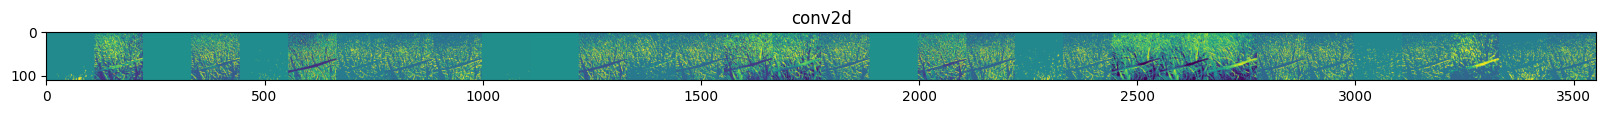

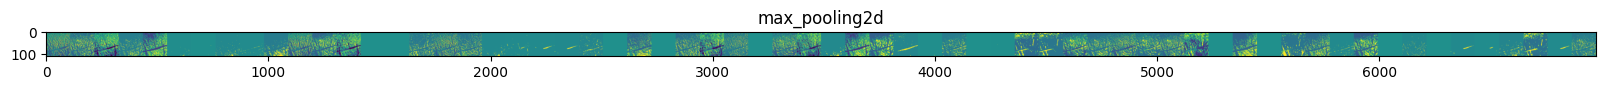

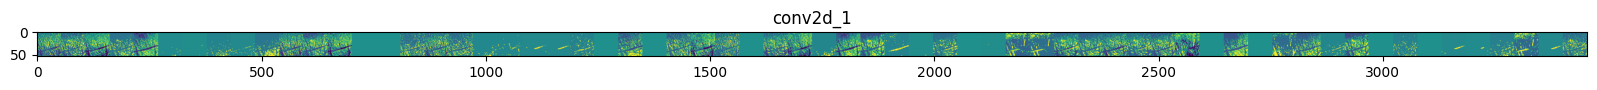

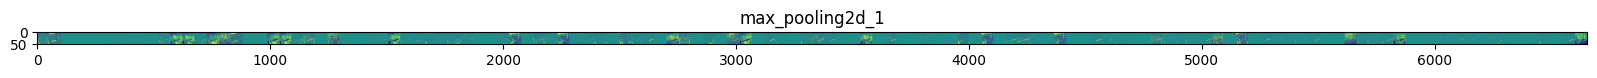

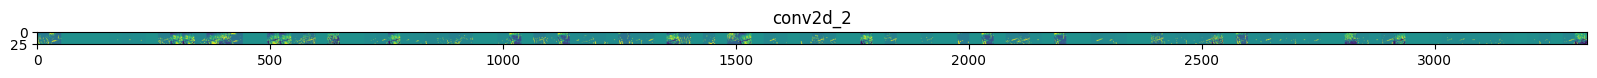

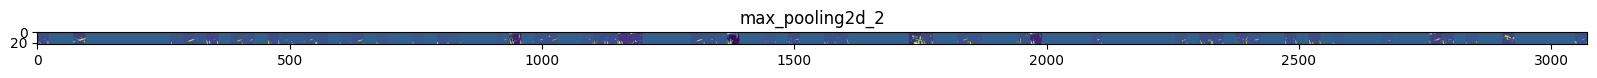

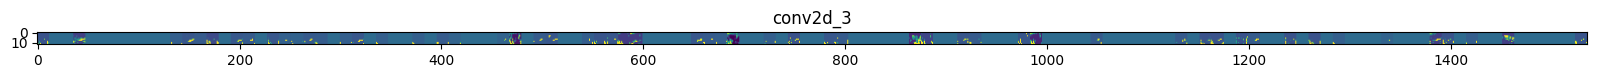

In [33]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# 🔥 WAJIB: aktifkan model dulu
dummy_input = np.zeros((1, 224, 224, 3))
model.predict(dummy_input)

# ambil output tiap layer
successive_outputs = [layer.output for layer in model.layers[1:]]

# buat model visualisasi
visualization_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=successive_outputs
)

# ambil file gambar
brownspot_img_files = [os.path.join(brownspot_dir, f) for f in brownspot_fnames]
leafsmut_img_files = [os.path.join(leafsmut_dir, f) for f in leafsmut_fnames]
tungro_img_files = [os.path.join(tungro_dir, f) for f in tungro_fnames]

img_path = random.choice(brownspot_img_files + leafsmut_img_files + tungro_img_files)

# load image
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x /= 255.0

# prediksi feature map
successive_feature_maps = visualization_model.predict(x)

layer_names = [layer.name for layer in model.layers]

# visualisasi
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:

        n_features = feature_map.shape[-1]
        size = feature_map.shape[1]

        display_grid = np.zeros((size, size * n_features))

        for i in range(n_features):
            fm = feature_map[0, :, :, i]
            fm -= fm.mean()
            fm /= (fm.std() + 1e-5)   # 🔥 biar gak error divide by zero
            fm *= 64
            fm += 128
            fm = np.clip(fm, 0, 255).astype('uint8')

            display_grid[:, i * size : (i + 1) * size] = fm

        scale = 20. / n_features
        plt.figure(figsize=(scale * n_features, scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

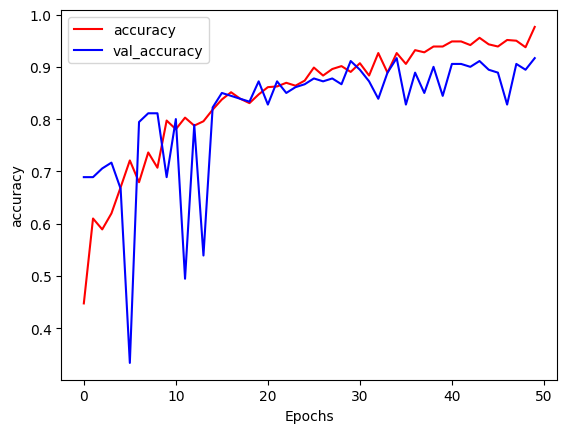

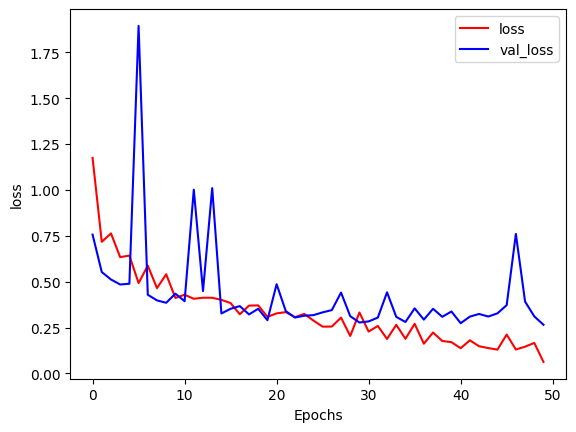

In [34]:
def plot_graphs(history, string):
  epochs = range(len(history.history[string]))
  plt.plot(epochs, history.history[string],'r', label=string)
  plt.plot(epochs, history.history['val_'+string],'b',label=string+'_val')
  plt.xlabel('Epochs')
  plt.ylabel(string)
  plt.legend([string,'val_'+string])
  plt.show()

plot_graphs(history,"accuracy")
plot_graphs(history,"loss")

Saving 108214.jpg to 108214.jpg


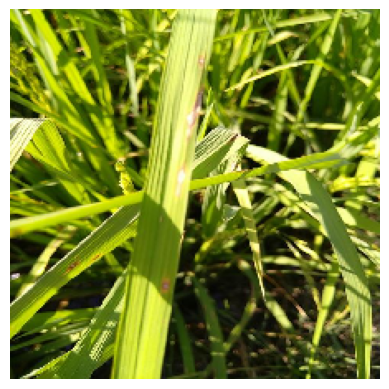

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[0. 1. 0.]]

Hasil prediksi: Leaf Smut


In [42]:
import numpy as np
from google.colab import files
from keras.preprocessing import image
import matplotlib.image as mpimg
%matplotlib inline

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = fn
  img = image.load_img(path, target_size=(224,224))
  plt.imshow(img)
  plt.axis('off')
  plt.show()
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes)

  print('\nHasil prediksi:',end=' ')
  if classes[0][0]==1:
    print('BrownSpot')
  elif classes[0][1]==1:
    print('Leaf Smut')
  elif classes[0][2]==1:
    print('Tungro')
  else:
    print('Unkown')